# Setup

In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [11]:
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
import scrnatools as rna
import numpy as np
import pandas as pd
import pickle
from scipy.stats import ttest_ind

In [3]:
# Setup figure params
plt.rcParams["pdf.use14corefonts"] = True
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = "Helvetica"
sc.set_figure_params(dpi=80, dpi_save=300, facecolor="white", frameon=False)
sns.set_context("paper")
plt.rcParams["axes.grid"] = False
plt.rcParams['axes.unicode_minus'] = False
cmap = sns.color_palette("colorblind")

In [4]:
warnings.resetwarnings()

# Import data

In [5]:
processedDataPath = "/mnt/iacchus/joe/processed_data/"

In [6]:
aire = sc.read(f"{processedDataPath}/Fezf2_thymus_paper/h5ad_files/pairwise_processing/aire_TECs.h5ad")
fezf2 = sc.read(f"{processedDataPath}/Fezf2_thymus_paper/h5ad_files/pairwise_processing/fezf2_TECs.h5ad")
scores = pd.read_csv("../../analysis/entropy/cell_x_gene_atlas_cell_type_entropy.csv", index_col=0)
scores = scores[scores.index.isin(aire.var_names)].copy()
aire = aire[:, aire.var_names.isin(scores.index)].copy()
fezf2 = fezf2[:, fezf2.var_names.isin(scores.index)].copy()

# TRA fraction (Aire)

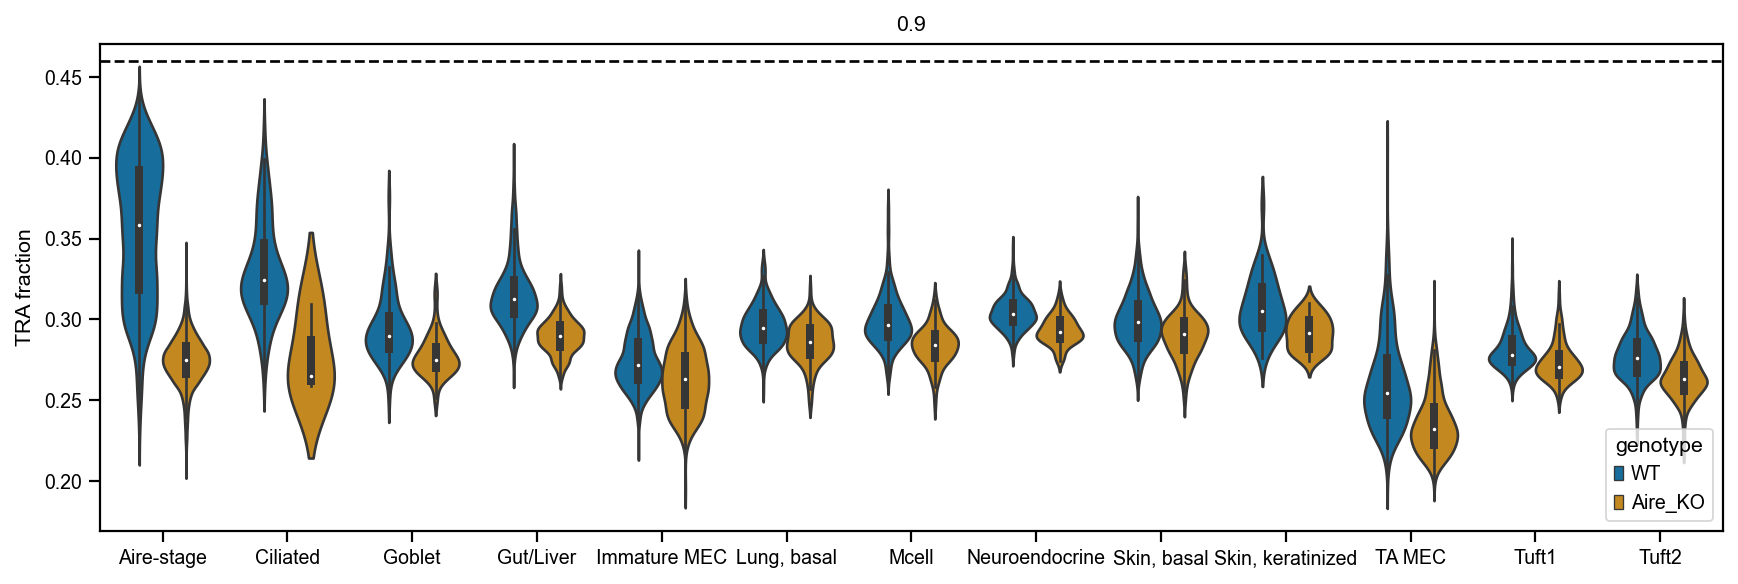

In [7]:
for tau_threshold in [0.9]:
    TRAs = scores[scores[f"tau_TRA_{tau_threshold}"] | scores[f"entropy_TRA_{tau_threshold}"]].index
    nonTRAs = scores[~scores.index.isin(TRAs)].index
    
    exprs = rna.tl.get_expression_matrix(aire, gene_data="scVI_normalized")
    exprs = exprs >= 0.1

    aire.obs[f"TRA_fraction_{tau_threshold}"] = exprs[TRAs].sum(axis=1)/exprs.sum(axis=1)
    aire.obs[f"TRA_number_{tau_threshold}"] = exprs[TRAs].sum(axis=1)

    plt.figure(figsize=(13,4))
    sns.violinplot(
        aire.obs,
        x="majority_voting",
        y=f"TRA_fraction_{tau_threshold}",
        hue="genotype",
        scale="width",
        width=0.75,
        hue_order=["WT", "Aire_KO"],
        palette=cmap[0:2],
    )
    plt.axhline(y=len(TRAs)/aire.shape[1], color="black", linestyle="--")
    plt.xlabel("")
    plt.ylabel("TRA fraction")
    plt.title(tau_threshold)
    plt.show()

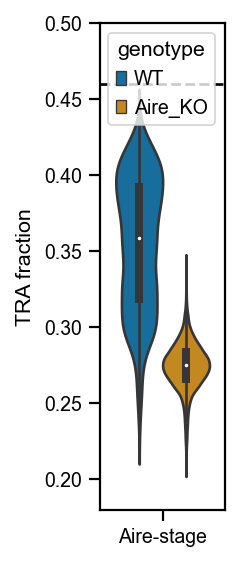

In [19]:
plt.figure(figsize=(1,4))
TRAs = scores[scores[f"tau_TRA_0.9"] | scores[f"entropy_TRA_0.9"]].index
sns.violinplot(
    aire[aire.obs.majority_voting == "Aire-stage"].obs,
    x="majority_voting",
    y=f"TRA_fraction_0.9",
    hue="genotype",
    scale="width",
    width=0.75,
    hue_order=["WT", "Aire_KO"],
    palette=cmap[0:2],
)
plt.ylim(0.18, 0.5)
plt.axhline(y=len(TRAs)/aire.shape[1], color="black", linestyle="--")
plt.xlabel("")
plt.ylabel("TRA fraction")
plt.savefig(f"../../analysis/individual_genotypes/aire_TRA_fraction.pdf")
plt.show()

In [21]:
wt_data = aire[aire.obs.genotype == "WT"]
ko_data = aire[aire.obs.genotype == "Aire_KO"]
ttest_ind(
    wt_data[wt_data.obs.majority_voting == "Aire-stage"].obs["TRA_fraction_0.9"],
    ko_data[ko_data.obs.majority_voting == "Aire-stage"].obs["TRA_fraction_0.9"]
)

TtestResult(statistic=167.2635184567651, pvalue=0.0, df=16409.0)

# TRA fraction (Fezf2)

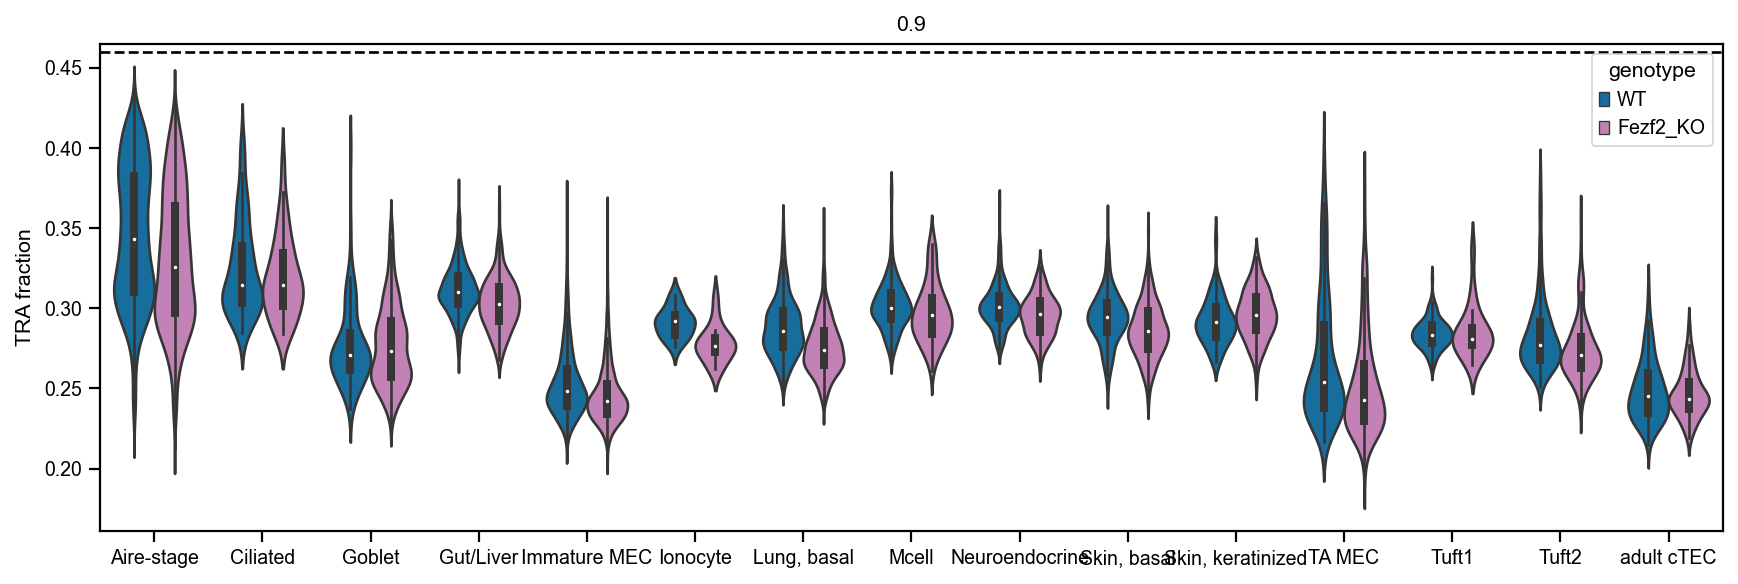

In [9]:
for tau_threshold in [0.9]:
    TRAs = scores[scores[f"tau_TRA_{tau_threshold}"] | scores[f"entropy_TRA_{tau_threshold}"]].index
    nonTRAs = scores[~scores.index.isin(TRAs)].index
    
    exprs = rna.tl.get_expression_matrix(fezf2, gene_data="scVI_normalized")
    exprs = exprs >= 0.1

    fezf2.obs[f"TRA_fraction_{tau_threshold}"] = exprs[TRAs].sum(axis=1)/exprs.sum(axis=1)
    fezf2.obs[f"TRA_number_{tau_threshold}"] = exprs[TRAs].sum(axis=1)

    plt.figure(figsize=(13,4))
    sns.violinplot(
        fezf2.obs,
        x="majority_voting",
        y=f"TRA_fraction_{tau_threshold}",
        hue="genotype",
        scale="width",
        width=0.75,
        hue_order=["WT", "Fezf2_KO"],
        palette=[cmap[0], cmap[4]],
    )
    plt.axhline(y=len(TRAs)/fezf2.shape[1], color="black", linestyle="--")
    plt.xlabel("")
    plt.ylabel("TRA fraction")
    plt.title(tau_threshold)
    plt.show()

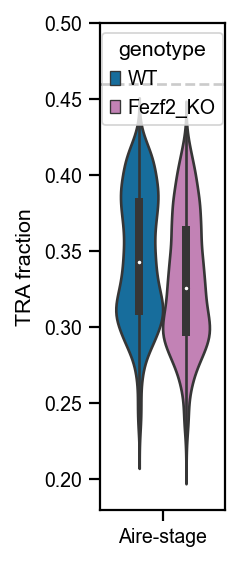

In [14]:
plt.figure(figsize=(1,4))
TRAs = scores[scores[f"tau_TRA_0.9"] | scores[f"entropy_TRA_0.9"]].index
sns.violinplot(
    fezf2[fezf2.obs.majority_voting == "Aire-stage"].obs,
    x="majority_voting",
    y=f"TRA_fraction_0.9",
    hue="genotype",
    scale="width",
    width=0.75,
    hue_order=["WT", "Fezf2_KO"],
    palette=[cmap[0], cmap[4]],
)
plt.ylim(0.18, 0.5)
plt.axhline(y=len(TRAs)/fezf2.shape[1], color="black", linestyle="--")
plt.xlabel("")
plt.ylabel("TRA fraction")
plt.savefig(f"../../analysis/individual_genotypes/fezf2_TRA_fraction.pdf")
plt.show()

In [22]:
wt_data = fezf2[fezf2.obs.genotype == "WT"]
ko_data = fezf2[fezf2.obs.genotype == "Fezf2_KO"]
ttest_ind(
    wt_data[wt_data.obs.majority_voting == "Aire-stage"].obs["TRA_fraction_0.9"],
    ko_data[ko_data.obs.majority_voting == "Aire-stage"].obs["TRA_fraction_0.9"]
)

TtestResult(statistic=16.77554872124765, pvalue=3.420259278524185e-62, df=8762.0)